# XAI Traffic Sign Recognition Explorer
Interactive notebook for visualizing model explanations across different traffic sign classes.

## Setup and Imports

In [1]:
import os
from pathlib import Path
import sys

# Change working directory to project root
if Path.cwd().name == 'notebooks':
    os.chdir('..')

# Add root to sys.path for module discovery
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import pickle
from typing import Dict, List, Tuple
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.gridspec import GridSpec
from torch.utils.data import DataLoader

# Imports using the src namespace
from src.data_preprocessing import GTSRBConfig, GTSRBDataset, get_transforms, load_splits
from src.models import (
    LogisticRegressionHOG,
    PretrainedMobileNetV2,
    PretrainedResNet18,
    ShallowCNN,
    get_model,
)
from src.utils import GTSRB_CLASS_NAMES, denormalize_image, overlay_heatmap
from src.xai_methods import (
    GradCAM,
    IntegratedGradients,
    OcclusionSensitivity,
    XAIEvaluator,
    get_target_layer,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100 # resolution

## Configuration

In [2]:
class ExplorerConfig:
    """Configuration for XAI Explorer."""
    
    # Paths
    PROCESSED_DIR: Path = Path("data/processed")
    MODELS_DIR: Path = Path("models")
    RESULTS_DIR: Path = Path("results/xai_visualizations")
    
    # Model checkpoints
    SHALLOW_CNN_PATH: Path = MODELS_DIR / "shallow_cnn.pth"
    MOBILENET_PATH: Path = MODELS_DIR / "mobilenet_phase2.pth"
    RESNET18_PATH: Path = MODELS_DIR / "resnet18_phase2.pth"
    LOGREG_PATH: Path = MODELS_DIR / "logistic_regression.pkl"
    
    # Device
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # XAI parameters
    GRADCAM_SAMPLES: int = 100
    IG_STEPS: int = 50
    OCCLUSION_SIZE: int = 8
    OCCLUSION_STRIDE: int = 4

ExplorerConfig.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using device: {ExplorerConfig.DEVICE}")

Using device: cuda


## Load Data

In [3]:
print("Loading data splits...")
splits: Dict[str, Tuple[np.ndarray, np.ndarray]] = load_splits(ExplorerConfig.PROCESSED_DIR)

# Create test dataset
test_dataset: GTSRBDataset = GTSRBDataset(
    image_paths=splits["test"][0],
    labels=splits["test"][1],
    transform=get_transforms(augment=False),
)

test_loader: DataLoader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True
)

print(f"Test set size: {len(test_dataset)}")

Loading data splits...
Test set size: 7776


## Load Models

### Logistic Regression

In [4]:
print("Loading Logistic Regression model...")
with open(ExplorerConfig.LOGREG_PATH, "rb") as f:
    logreg_model: LogisticRegressionHOG = pickle.load(f)

# Load HOG features for test set
with open(ExplorerConfig.PROCESSED_DIR / "test_hog_features.pkl", "rb") as f:
    test_hog_features: np.ndarray = pickle.load(f)

print("✓ Logistic Regression model loaded")

Loading Logistic Regression model...
✓ Logistic Regression model loaded


### CNN Models

In [5]:
print("Loading CNN models...")

# Shallow CNN
shallow_cnn: ShallowCNN = get_model(
    "shallow_cnn", 
    num_classes=GTSRBConfig.NUM_CLASSES, 
    device=ExplorerConfig.DEVICE
)
shallow_cnn.load_state_dict(
    torch.load(ExplorerConfig.SHALLOW_CNN_PATH, map_location=ExplorerConfig.DEVICE)
)
shallow_cnn.eval()
print("✓ Shallow CNN loaded")

# MobileNetV2
mobilenet: PretrainedMobileNetV2 = get_model(
    "mobilenet", 
    num_classes=GTSRBConfig.NUM_CLASSES, 
    pretrained=False, 
    device=ExplorerConfig.DEVICE
)
mobilenet.load_state_dict(
    torch.load(ExplorerConfig.MOBILENET_PATH, map_location=ExplorerConfig.DEVICE)
)
mobilenet.eval()
print("✓ MobileNetV2 loaded")

# ResNet18
resnet18: PretrainedResNet18 = get_model(
    "resnet18", 
    num_classes=GTSRBConfig.NUM_CLASSES, 
    pretrained=False, 
    device=ExplorerConfig.DEVICE
)
resnet18.load_state_dict(
    torch.load(ExplorerConfig.RESNET18_PATH, map_location=ExplorerConfig.DEVICE)
)
resnet18.eval()
print("✓ ResNet18 loaded")

Loading CNN models...
✓ Shallow CNN loaded
✓ MobileNetV2 loaded
✓ ResNet18 loaded


## Initialize XAI Methods

In [6]:
print("Initializing XAI methods...")

# Shallow CNN XAI
shallow_gradcam: GradCAM = GradCAM(
    shallow_cnn, get_target_layer(shallow_cnn, "shallow_cnn")
)
shallow_ig: IntegratedGradients = IntegratedGradients(shallow_cnn)
shallow_occlusion: OcclusionSensitivity = OcclusionSensitivity(
    shallow_cnn,
    occlusion_size=14,
    occlusion_stride=2,
    # occlusion_size=ExplorerConfig.OCCLUSION_SIZE,
    # occlusion_stride=ExplorerConfig.OCCLUSION_STRIDE,
)

# MobileNetV2 XAI
mobilenet_gradcam: GradCAM = GradCAM(
    mobilenet, get_target_layer(mobilenet, "mobilenet")
)
mobilenet_ig: IntegratedGradients = IntegratedGradients(mobilenet)
mobilenet_occlusion: OcclusionSensitivity = OcclusionSensitivity(
    mobilenet,
    occlusion_size=ExplorerConfig.OCCLUSION_SIZE,
    occlusion_stride=ExplorerConfig.OCCLUSION_STRIDE,
)

# ResNet18 XAI
resnet_gradcam: GradCAM = GradCAM(
    resnet18, get_target_layer(resnet18, "resnet18")
)
resnet_ig: IntegratedGradients = IntegratedGradients(resnet18)
resnet_occlusion: OcclusionSensitivity = OcclusionSensitivity(
    resnet18,
    occlusion_size=ExplorerConfig.OCCLUSION_SIZE,
    occlusion_stride=ExplorerConfig.OCCLUSION_STRIDE,
)

print("XAI methods initialized")

Initializing XAI methods...
XAI methods initialized


## Helper Functions

In [7]:
def get_sample_by_class(
    class_id: int, dataset: GTSRBDataset, index: int = 0
) -> Tuple[torch.Tensor, int]:
    """Get a specific sample from a class."""
    class_indices: List[int] = [
        i for i, label in enumerate(dataset.labels) if label == class_id
    ]
    
    if not class_indices:
        raise ValueError(f"No samples found for class {class_id}")
    
    if index >= len(class_indices):
        index = 0
        print(f"Index {index} out of range. Using first sample (index=0)")
    
    sample_idx: int = class_indices[index]
    return dataset[sample_idx]


def normalize_heatmap(heatmap: np.ndarray) -> np.ndarray:
    """Normalize heatmap to [0, 1] range."""
    heatmap = heatmap - heatmap.min()
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap

---
# 1. Logistic Regression: Coefficient Analysis

In [15]:
def visualize_logreg_coefficients(
    model: LogisticRegressionHOG, class_id: int, top_k: int = 20
) -> None:
    """Visualize top-k coefficients for logistic regression."""
    coefficients: np.ndarray = model.model.coef_[class_id]
    
    # Get top-k positive and negative coefficients
    top_positive_idx: np.ndarray = np.argsort(coefficients)[-top_k:][::-1]
    top_negative_idx: np.ndarray = np.argsort(coefficients)[:top_k]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top positive coefficients
    ax1.barh(range(top_k), coefficients[top_positive_idx], color='green', alpha=0.7)
    ax1.set_yticks(range(top_k))
    ax1.set_yticklabels([f"Feature {idx}" for idx in top_positive_idx])
    ax1.set_xlabel("Coefficient Value")
    ax1.set_title(f"Top {top_k} Positive Coefficients\nClass {class_id}: {GTSRB_CLASS_NAMES[class_id]}")
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Top negative coefficients
    ax2.barh(range(top_k), coefficients[top_negative_idx], color='red', alpha=0.7)
    ax2.set_yticks(range(top_k))
    ax2.set_yticklabels([f"Feature {idx}" for idx in top_negative_idx])
    ax2.set_xlabel("Coefficient Value")
    ax2.set_title(f"Top {top_k} Negative Coefficients\nClass {class_id}: {GTSRB_CLASS_NAMES[class_id]}")
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Explore Logistic Regression Coefficients
**Change `TARGET_CLASS` to explore different classes:**

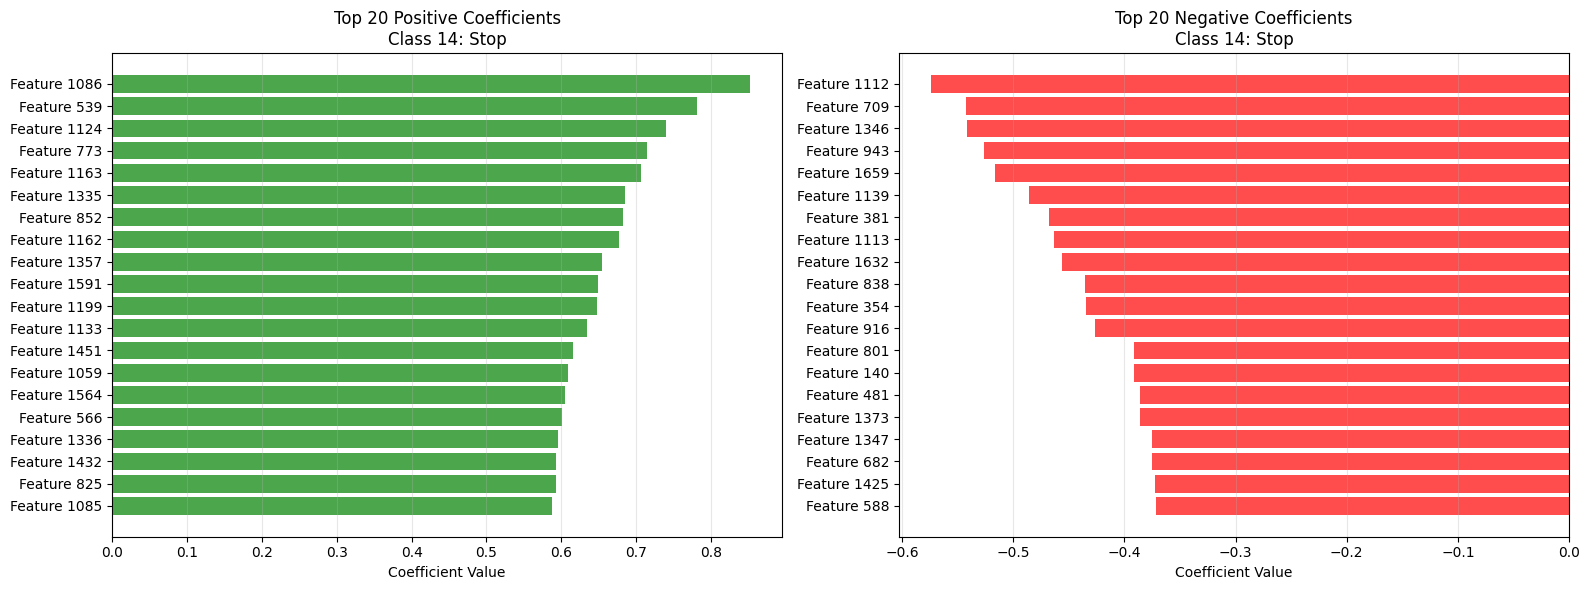


Class 14: Stop
Number of features: 1764
Mean coefficient: 0.0130
Std coefficient: 0.1895
Max coefficient: 0.8524
Min coefficient: -0.5740


In [16]:
# ============= CHANGE THIS =============
TARGET_CLASS: int = 14  # Stop sign
# =======================================

visualize_logreg_coefficients(logreg_model, TARGET_CLASS, top_k=20)

# Show coefficient statistics
coeffs: np.ndarray = logreg_model.model.coef_[TARGET_CLASS]
print(f"\nClass {TARGET_CLASS}: {GTSRB_CLASS_NAMES[TARGET_CLASS]}")
print(f"Number of features: {len(coeffs)}")
print(f"Mean coefficient: {coeffs.mean():.4f}")
print(f"Std coefficient: {coeffs.std():.4f}")
print(f"Max coefficient: {coeffs.max():.4f}")
print(f"Min coefficient: {coeffs.min():.4f}")

---
# 2. Local XAI Explanations (Single Instance)

## Visualize Local Explanations for All Models
**Change `TARGET_CLASS` and `SAMPLE_INDEX` to explore different instances:**

In [10]:
# ============= CHANGE THIS =============
TARGET_CLASS: int = 14  # Stop sign
SAMPLE_INDEX: int = 0   # First sample of this class
# =======================================

# Get sample
image_tensor, true_label = get_sample_by_class(TARGET_CLASS, test_dataset, SAMPLE_INDEX)
image_tensor = image_tensor.unsqueeze(0).to(ExplorerConfig.DEVICE)

# Denormalize for visualization
image_np: np.ndarray = denormalize_image(image_tensor.squeeze(0).cpu())

print(f"Visualizing Class {TARGET_CLASS}: {GTSRB_CLASS_NAMES[TARGET_CLASS]}")
print(f"Sample index: {SAMPLE_INDEX}")

Visualizing Class 14: Stop
Sample index: 0


### Shallow CNN Explanations


=== Shallow CNN ===


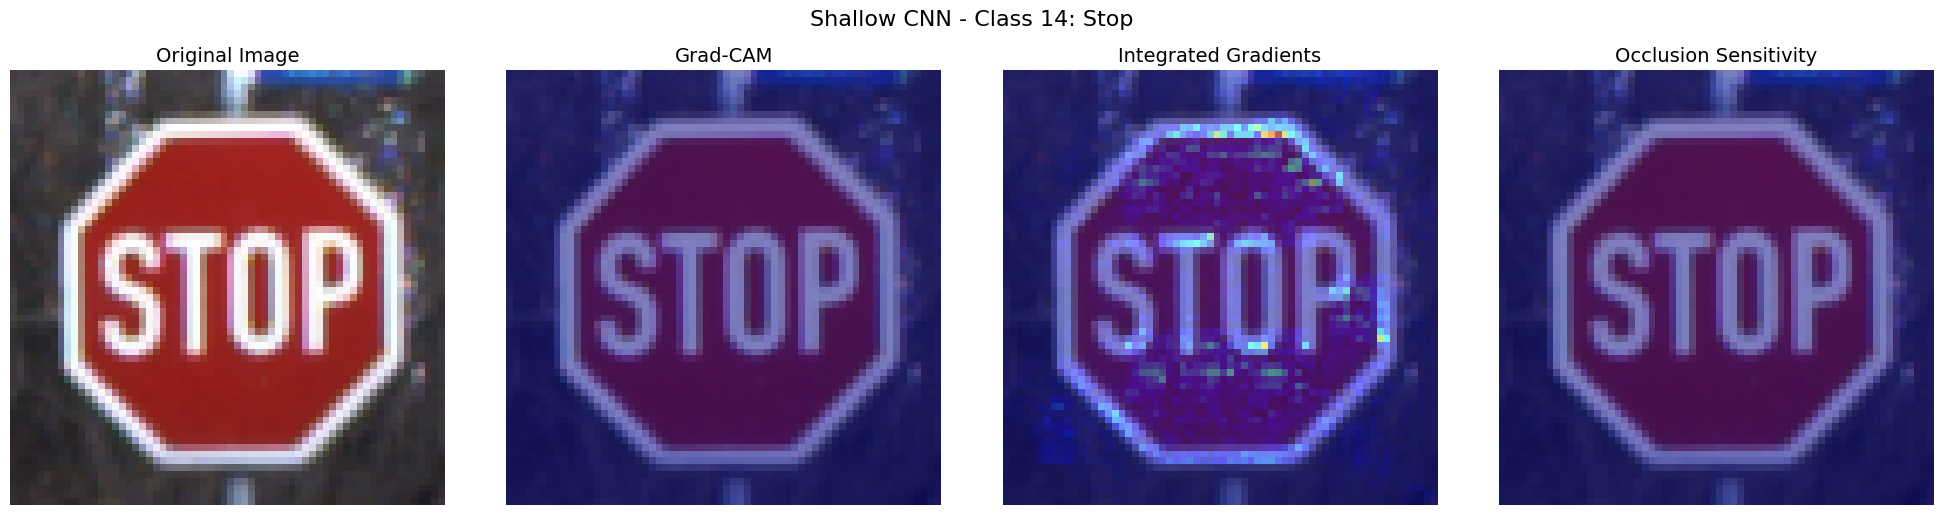

In [11]:
print("\n=== Shallow CNN ===")

# Grad-CAM
gradcam_shallow: np.ndarray = shallow_gradcam.generate_cam(image_tensor, TARGET_CLASS)

# Integrated Gradients
ig_shallow: np.ndarray = shallow_ig.generate_attribution(
    image_tensor, TARGET_CLASS, steps=ExplorerConfig.IG_STEPS
)
ig_shallow_norm: np.ndarray = normalize_heatmap(np.abs(ig_shallow).sum(axis=2))

# Occlusion Sensitivity
occlusion_shallow: np.ndarray = shallow_occlusion.generate_sensitivity_map(
    image_tensor, TARGET_CLASS
)
occlusion_shallow_norm: np.ndarray = normalize_heatmap(occlusion_shallow)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_np)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(overlay_heatmap(image_np, gradcam_shallow, alpha=0.5))
axes[1].set_title("Grad-CAM", fontsize=14)
axes[1].axis('off')

axes[2].imshow(overlay_heatmap(image_np, ig_shallow_norm, alpha=0.5))
axes[2].set_title("Integrated Gradients", fontsize=14)
axes[2].axis('off')

axes[3].imshow(overlay_heatmap(image_np, occlusion_shallow_norm, alpha=0.5))
axes[3].set_title("Occlusion Sensitivity", fontsize=14)
axes[3].axis('off')

plt.suptitle(f"Shallow CNN - Class {TARGET_CLASS}: {GTSRB_CLASS_NAMES[TARGET_CLASS]}", 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### MobileNetV2 Explanations


=== MobileNetV2 ===


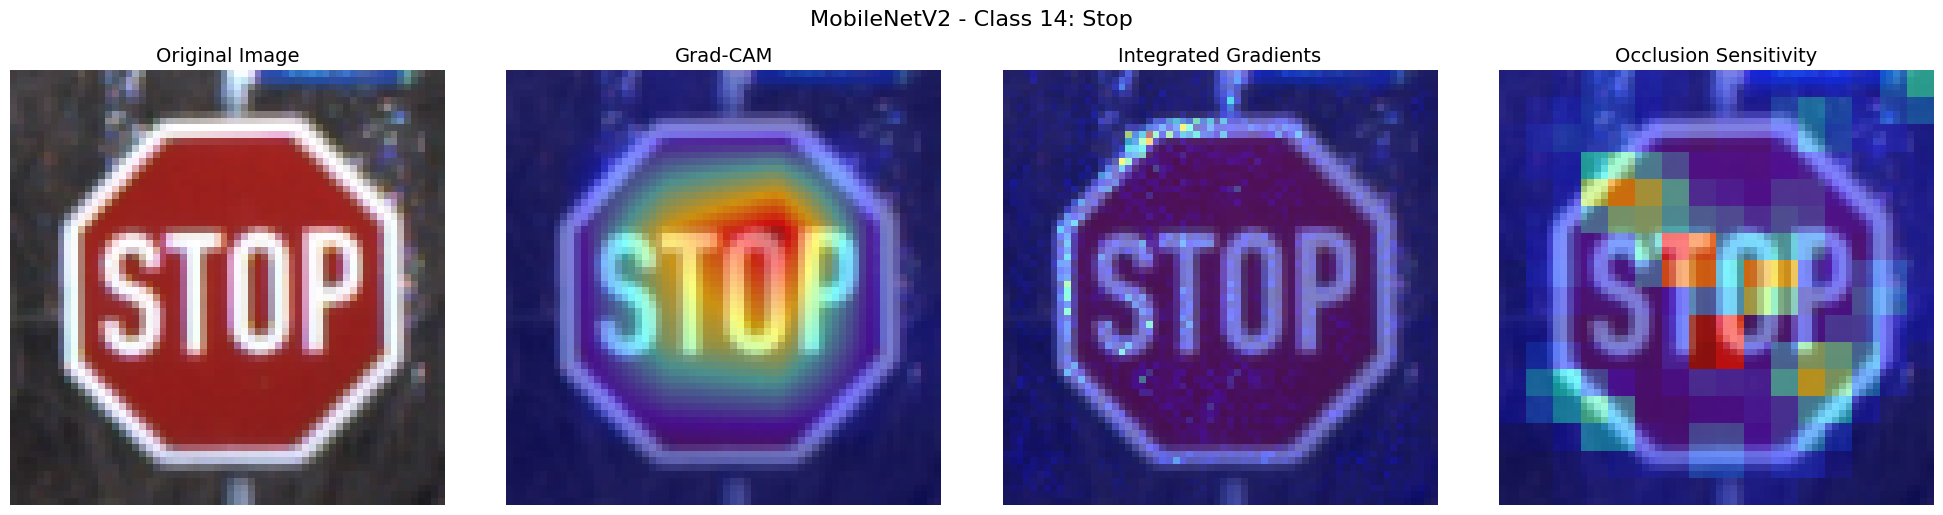

In [12]:
print("\n=== MobileNetV2 ===")

# Grad-CAM
gradcam_mobilenet: np.ndarray = mobilenet_gradcam.generate_cam(image_tensor, TARGET_CLASS)

# Integrated Gradients
ig_mobilenet: np.ndarray = mobilenet_ig.generate_attribution(
    image_tensor, TARGET_CLASS, steps=ExplorerConfig.IG_STEPS
)
ig_mobilenet_norm: np.ndarray = normalize_heatmap(np.abs(ig_mobilenet).sum(axis=2))

# Occlusion Sensitivity
occlusion_mobilenet: np.ndarray = mobilenet_occlusion.generate_sensitivity_map(
    image_tensor, TARGET_CLASS
)
occlusion_mobilenet_norm: np.ndarray = normalize_heatmap(occlusion_mobilenet)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_np)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(overlay_heatmap(image_np, gradcam_mobilenet, alpha=0.5))
axes[1].set_title("Grad-CAM", fontsize=14)
axes[1].axis('off')

axes[2].imshow(overlay_heatmap(image_np, ig_mobilenet_norm, alpha=0.5))
axes[2].set_title("Integrated Gradients", fontsize=14)
axes[2].axis('off')

axes[3].imshow(overlay_heatmap(image_np, occlusion_mobilenet_norm, alpha=0.5))
axes[3].set_title("Occlusion Sensitivity", fontsize=14)
axes[3].axis('off')

plt.suptitle(f"MobileNetV2 - Class {TARGET_CLASS}: {GTSRB_CLASS_NAMES[TARGET_CLASS]}", 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### ResNet18 Explanations


=== ResNet18 ===


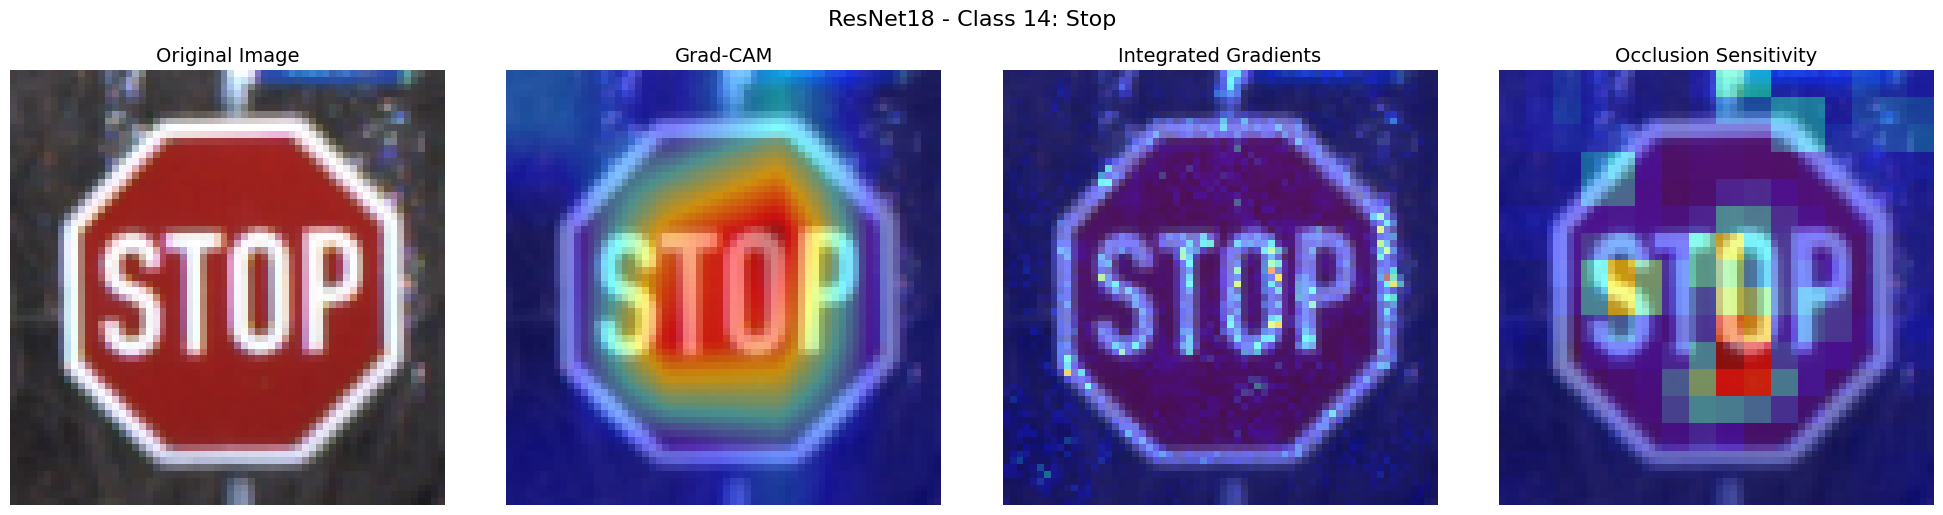

In [13]:
print("\n=== ResNet18 ===")

# Grad-CAM
gradcam_resnet: np.ndarray = resnet_gradcam.generate_cam(image_tensor, TARGET_CLASS)

# Integrated Gradients
ig_resnet: np.ndarray = resnet_ig.generate_attribution(
    image_tensor, TARGET_CLASS, steps=ExplorerConfig.IG_STEPS
)
ig_resnet_norm: np.ndarray = normalize_heatmap(np.abs(ig_resnet).sum(axis=2))

# Occlusion Sensitivity
occlusion_resnet: np.ndarray = resnet_occlusion.generate_sensitivity_map(
    image_tensor, TARGET_CLASS
)
occlusion_resnet_norm: np.ndarray = normalize_heatmap(occlusion_resnet)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_np)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(overlay_heatmap(image_np, gradcam_resnet, alpha=0.5))
axes[1].set_title("Grad-CAM", fontsize=14)
axes[1].axis('off')

axes[2].imshow(overlay_heatmap(image_np, ig_resnet_norm, alpha=0.5))
axes[2].set_title("Integrated Gradients", fontsize=14)
axes[2].axis('off')

axes[3].imshow(overlay_heatmap(image_np, occlusion_resnet_norm, alpha=0.5))
axes[3].set_title("Occlusion Sensitivity", fontsize=14)
axes[3].axis('off')

plt.suptitle(f"ResNet18 - Class {TARGET_CLASS}: {GTSRB_CLASS_NAMES[TARGET_CLASS]}", 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Compare All Models Side-by-Side

/tmp/ipykernel_24417/770616312.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


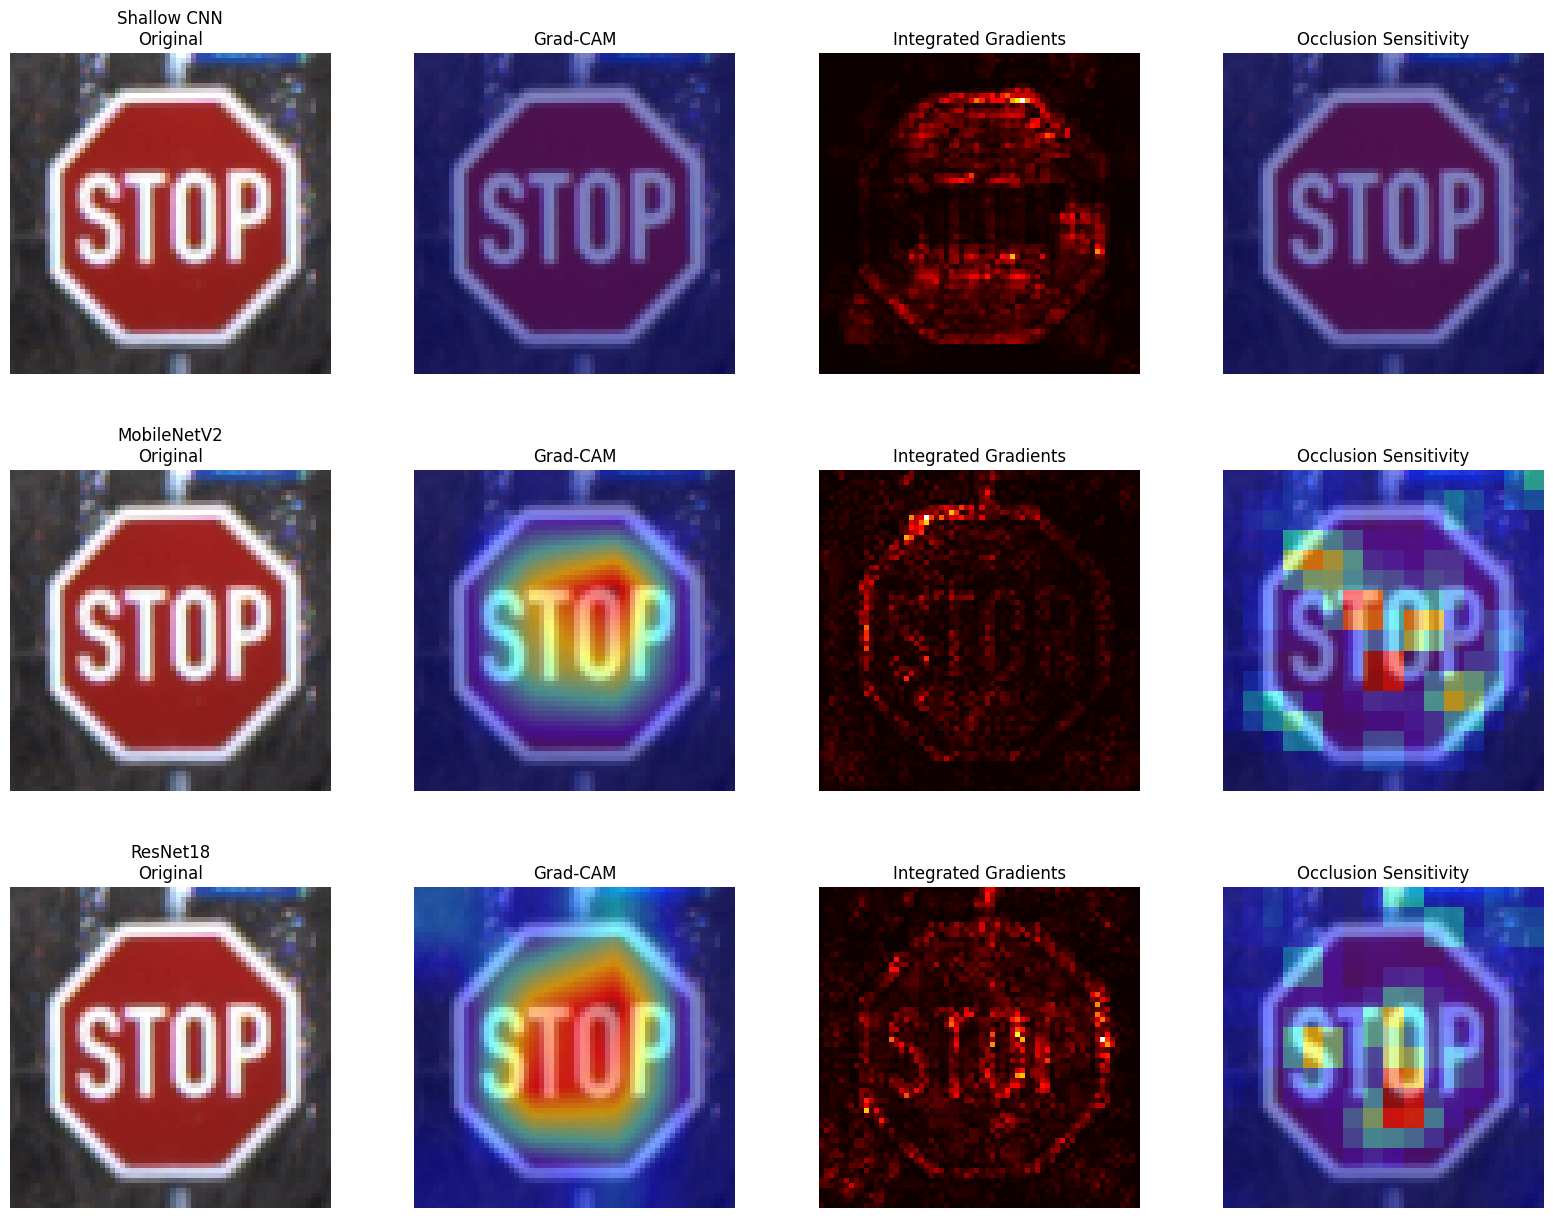

In [14]:
# Create comprehensive comparison
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.2)

models_data = [
    ("Shallow CNN", gradcam_shallow, ig_shallow_norm, occlusion_shallow_norm),
    ("MobileNetV2", gradcam_mobilenet, ig_mobilenet_norm, occlusion_mobilenet_norm),
    ("ResNet18", gradcam_resnet, ig_resnet_norm, occlusion_resnet_norm),
]

for row, (model_name, gradcam, ig, occlusion) in enumerate(models_data):
    # Original image
    ax = fig.add_subplot(gs[row, 0])
    ax.imshow(image_np)
    ax.set_title(f"{model_name}\nOriginal", fontsize=12)
    ax.axis('off')
    
    # Grad-CAM
    ax = fig.add_subplot(gs[row, 1])
    ax.imshow(overlay_heatmap(image_np, gradcam, alpha=0.5))
    # Grad-CAM title and axis
    ax.set_title("Grad-CAM", fontsize=12)
    ax.axis('off')
    # Integrated Gradients
    ax = fig.add_subplot(gs[row, 2])
    ax.imshow(ig, cmap='hot')
    ax.set_title("Integrated Gradients", fontsize=12)
    ax.axis('off')
    # Occlusion Sensitivity
    ax = fig.add_subplot(gs[row, 3])
    ax.imshow(overlay_heatmap(image_np, occlusion, alpha=0.5))
    ax.set_title("Occlusion Sensitivity", fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()
